# Optimal quoting — complete-market case (Theorem 1)

Phase 2 of the option market-making system: Stoikov & Sağlam (2009), *"Option market making under inventory risk"*, Section II. This is the simplest of the paper's three quoting regimes — the underlying trades continuously with no transaction costs, so the dealer removes all inventory risk from an option position by delta-hedging in the underlying at every instant.

**Theorem 1's punchline:** once continuous hedging is available, the optimal bid/ask premiums around the option's Black-Scholes mid depend only on the *liquidity* of the option (the order-arrival intensity `lambda_o`), and **not on inventory**. Inventory only ever shows up in how much stock the dealer holds as a hedge:

$$\pi_t = -S_t \Delta_t q_t^o$$

This notebook:
1. Builds a live vol surface with the Phase 1 pipeline (`surface.run_pipeline`)
2. Calibrates the order-arrival intensity `lambda_o(eps) = C - D*eps` from Deribit's real trade tape (`market_making.calibration`), separately for the bid and ask side
3. Computes the optimal quote for a single option, reading Greeks and implied vol straight off the surface, using the calibrated intensity
4. Demonstrates Theorem 1's central claim directly: sweep inventory `q_o` and show the quoted premiums stay exactly flat while the hedge scales linearly
5. Applies the same quoting policy across a slice of the live option chain, re-deriving the absolute intensity at each strike's own price level

New code lives in `src/market_making/quoting.py` and `src/market_making/calibration.py`.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('../src'))
sys.path.insert(0, os.path.abspath('../src/vol_surface'))

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import bs
import surface
from market_making import quoting

%matplotlib inline
np.set_printoptions(precision=6, suppress=True)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

## 1. Build the vol surface (Phase 1, reused as-is)

Nothing new here — this is the exact pipeline from `notebooks/vol_surface_pipeline.ipynb`: live Deribit chain → per-expiry SVI fits → no-arbitrage validation → queryable `surface.implied_vol(K, T)`. The quoting layer below consumes this surface's output; it does not refit anything.

In [2]:
with warnings.catch_warnings():
    warnings.simplefilter('ignore')  # illiquid-wing slice skips, not relevant here
    surf = surface.run_pipeline('BTC')

print(f"Fitted {len(surf.maturities)} expiries, T = {surf.maturities}")
print(f"Forwards = {surf.forwards}")
print(f"Strike bounds = {surf.strike_bounds}")

Fitted 8 expiries, T = [0.005443 0.008183 0.010922 0.046539 0.219142 0.372566 0.621881 0.871196]
Forwards = [64002.24     64006.47     64013.254286 64111.86     64569.07
 65001.74     65686.04     66403.03    ]
Strike bounds = (20000.0, 320000.0)


## 1b. Calibrate the order-arrival intensity from real fills

Rather than guessing `C`, `D`, fit them from Deribit's public trade tape (`market_making.calibration`): every historical trade reports both the executed price and Deribit's `mark_price` at that instant, so `|price - mark_price|` is a direct per-trade estimate of how far from fair value that fill happened. A marketable order that trades at distance `eps` from the mark necessarily filled every resting order between the mark and that price — so the empirical **survival rate** (trades at distance >= eps, per unit time) is exactly the fill rate a passive quote resting at `eps` would have realized.

`direction` on each trade also splits the tape into bid-side and ask-side fills (a buy aggressor lifts a resting ask; a sell aggressor hits a resting bid), so this recovers separate bid/ask intensities rather than assuming symmetric liquidity.

Any single option contract trades too rarely to fit this alone (a liquid BTC option prints only a few dozen trades a day), so the fit pools trades across the most active instruments on the chain, with premiums expressed *relative* to each option's own mark price (`eps / mark`) so contracts at very different price levels are comparable. `RelativeIntensity.to_absolute(mid)` converts the fitted curve into an absolute-dollar `LinearIntensity` for any specific option's current mid.

In [3]:
from market_making import calibration
import data

raw_book = data.fetch_book_summary('BTC')
top_instruments = [
    x['instrument_name'] for x in sorted(raw_book.to_dict('records'), key=lambda x: -(x.get('volume') or 0))[:30]
    if (x.get('volume') or 0) > 0
]
print(f"pooling trades across {len(top_instruments)} most-active instruments")

trades = calibration.fetch_trades_multi(top_instruments, count_each=1000)
print(f"pooled {len(trades)} trades")

fit = calibration.calibrate_intensity(trades, min_trades_per_side=20, n_bins=15)
for side, res in [('bid', fit.bid), ('ask', fit.ask)]:
    print(f"{side}: n={res.n_trades}  window={res.window_seconds/3600:.1f}h  "
          f"C={res.intensity.C:.6f}  D={res.intensity.D:.4f}  "
          f"max relative premium C/D={res.intensity.C/res.intensity.D:.4f}")

# reused by step 2's real-width comparison
chain_raw = data.build_chain(raw_book)
chain_raw['width'] = chain_raw['ask'] - chain_raw['bid']

pooling trades across 30 most-active instruments


pooled 1294 trades
bid: n=759  window=24.0h  C=0.004729  D=0.0448  max relative premium C/D=0.1056
ask: n=535  window=24.0h  C=0.003672  D=0.0321  max relative premium C/D=0.1145


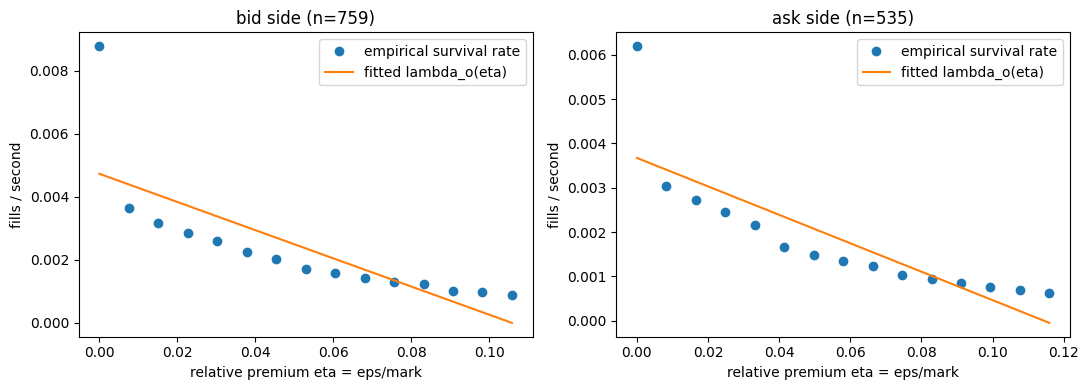

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, side, res in zip(axes, ['bid', 'ask'], [fit.bid, fit.ask]):
    ax.plot(res.eps_grid, res.empirical_rate, 'o', label='empirical survival rate')
    ax.plot(res.eps_grid, res.fitted_rate, '-', label='fitted lambda_o(eta)')
    ax.set_xlabel('relative premium eta = eps/mark')
    ax.set_ylabel('fills / second')
    ax.set_title(f'{side} side (n={res.n_trades})')
    ax.legend()
plt.tight_layout()

## 2. Compare: placeholder vs. calibrated intensity

Pick a near-ATM option and convert the calibrated *relative* intensities to this option's own dollar scale via `RelativeIntensity.to_absolute(mid)`. Compare the resulting spread against both the old placeholder (`LinearIntensity(C=40, D=200)`, what the first version of this notebook used) and the option's actual observed live bid-ask width, pulled straight from the chain.

In [5]:
r, q = 0.0, 0.0  # crypto perp/spot convention: no funding/dividend yield modeled here

T0 = float(surf.maturities[len(surf.maturities) // 2])
F0 = float(np.interp(T0, surf.maturities, surf.forwards))
K0 = round(F0 / 500) * 500  # round to a realistic Deribit strike increment
S0 = F0

mid0 = float(bs.price(S0, K0, T0, r, q, surf.implied_vol(K0, T0), 'C'))

placeholder_intensity = quoting.LinearIntensity(C=40.0, D=200.0)
calibrated_bid = fit.bid.intensity.to_absolute(mid0)
calibrated_ask = fit.ask.intensity.to_absolute(mid0)

placeholder_spread = 2 * quoting.optimal_premium(placeholder_intensity)
calibrated_spread = quoting.optimal_premium(calibrated_bid) + quoting.optimal_premium(calibrated_ask)

print(f"option: K={K0:.0f}  T={T0:.4f}  mid={mid0:,.2f}\n")
print(f"placeholder total spread (old notebook) = {placeholder_spread:,.2f}")
print(f"calibrated total spread                 = {calibrated_spread:,.2f}")

# compare against this option's actual observed live bid-ask width
nearby = chain_raw[(chain_raw['T'].sub(T0).abs() < 0.02) & (chain_raw['strike'].sub(K0).abs() < 3000)]
if not nearby.empty:
    print(f"real observed width nearby (n={len(nearby)})     = {nearby['width'].median():,.2f}")
else:
    print("no live quotes close enough to K0/T0 to compare directly")

option: K=64500  T=0.2191  mid=4,542.85

placeholder total spread (old notebook) = 0.20
calibrated total spread                 = 499.86
real observed width nearby (n=12)     = 96.85


## 3. Quote the option using the calibrated intensity

Same `quoting.quote_option` call as before, but now with `calibrated_bid`/`calibrated_ask` instead of a guessed placeholder.

In [6]:
quote = quoting.quote_option(S0, K0, T0, r, q, surf.implied_vol(K0, T0), 'C',
                              calibrated_bid, ask_intensity=calibrated_ask, q_o=0.0)
print(f"S={S0:.0f}  K={K0:.0f}  T={T0:.4f}\n")
print(f"mid        = {quote.mid:,.2f}")
print(f"bid / ask  = {quote.bid_price:,.2f} / {quote.ask_price:,.2f}  (premiums = {quote.bid_premium:.2f} / {quote.ask_premium:.2f})")
print(f"delta      = {quote.delta:.4f}")
print(f"gamma      = {quote.gamma:.6f}")
print(f"vega       = {quote.vega:,.2f}")
print(f"theta      = {quote.theta:,.2f}")
print(f"hedge (q_o=0) shares/notional = {quote.hedge_shares:.4f} / {quote.hedge_notional:,.2f}")

S=64569  K=64500  T=0.2191

mid        = 4,542.85
bid / ask  = 4,303.02 / 4,802.88  (premiums = 239.83 / 260.03)
delta      = 0.5374
gamma      = 0.000035
vega       = 12,005.70
theta      = -10,259.59
hedge (q_o=0) shares/notional = -0.0000 / -0.00


## 4. Theorem 1's central claim: quotes are inventory-independent

Sweep the option inventory `q_o` from short to long and recompute the quote at every level. Per Theorem 1, `bid_price`/`ask_price` should be **exactly flat** — only the hedge (`hedge_shares`, `hedge_notional = pi_t`) should move, linearly in `q_o` via `-Delta * q_o`.

In [7]:
inventory_grid = np.linspace(-50, 50, 21)
rows = []
for q_o in inventory_grid:
    qt = quoting.quote_option(S0, K0, T0, r, q, surf.implied_vol(K0, T0), 'C',
                               calibrated_bid, ask_intensity=calibrated_ask, q_o=q_o)
    rows.append(dict(q_o=q_o, bid_price=qt.bid_price, ask_price=qt.ask_price,
                      hedge_shares=qt.hedge_shares, hedge_notional=qt.hedge_notional))
inv_df = pd.DataFrame(rows)

print(f"distinct bid prices across inventory sweep: {inv_df.bid_price.nunique()}")
print(f"distinct ask prices across inventory sweep: {inv_df.ask_price.nunique()}")
inv_df.head()

distinct bid prices across inventory sweep: 1
distinct ask prices across inventory sweep: 1


,q_o,bid_price,ask_price,hedge_shares,hedge_notional
0,-50.0000,"4,303.0181","4,802.8765",26.8677,"1,734,822.6595"
1,-45.0000,"4,303.0181","4,802.8765",24.1809,"1,561,340.3936"
2,-40.0000,"4,303.0181","4,802.8765",21.4942,"1,387,858.1276"
3,-35.0000,"4,303.0181","4,802.8765",18.8074,"1,214,375.8617"
4,-30.0000,"4,303.0181","4,802.8765",16.1206,"1,040,893.5957"


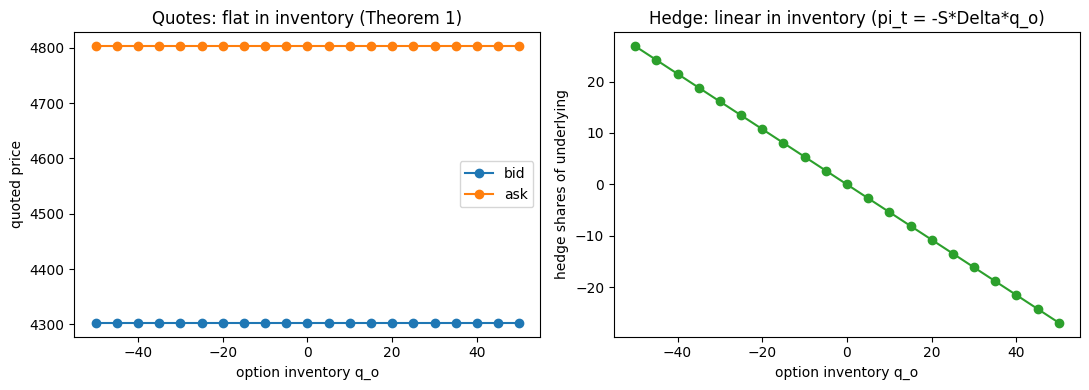

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(inv_df.q_o, inv_df.bid_price, 'o-', label='bid')
axes[0].plot(inv_df.q_o, inv_df.ask_price, 'o-', label='ask')
axes[0].set_xlabel('option inventory q_o'); axes[0].set_ylabel('quoted price')
axes[0].set_title('Quotes: flat in inventory (Theorem 1)'); axes[0].legend()

axes[1].plot(inv_df.q_o, inv_df.hedge_shares, 'o-', color='C2')
axes[1].set_xlabel('option inventory q_o'); axes[1].set_ylabel('hedge shares of underlying')
axes[1].set_title('Hedge: linear in inventory (pi_t = -S*Delta*q_o)')
plt.tight_layout()

## 5. Quoting across a chain slice

Apply the same policy across every strike at the chosen expiry, still with zero inventory — this is the shape of what a live quoting loop would publish.

In [9]:
strike_lo, strike_hi = surf.strike_bounds
strikes = np.round(np.linspace(max(strike_lo, F0 * 0.7), min(strike_hi, F0 * 1.3), 15) / 500) * 500
strikes = np.unique(strikes)

chain_rows = []
for K in strikes:
    otype = 'C' if K >= F0 else 'P'
    sigma_K = surf.implied_vol(float(K), T0)
    mid_K = float(bs.price(S0, float(K), T0, r, q, sigma_K, otype))
    bid_int_K = fit.bid.intensity.to_absolute(mid_K)
    ask_int_K = fit.ask.intensity.to_absolute(mid_K)
    qt = quoting.quote_option(S0, float(K), T0, r, q, sigma_K, otype, bid_int_K, ask_intensity=ask_int_K, q_o=0.0)
    chain_rows.append(dict(K=K, type=otype, mid=qt.mid, bid=qt.bid_price, ask=qt.ask_price,
                            delta=qt.delta, gamma=qt.gamma, vega=qt.vega))
chain_df = pd.DataFrame(chain_rows)
chain_df

,K,type,mid,bid,ask,delta,gamma,vega
0,"45,000.0000",P,406.7793,385.3042,430.0629,-0.0551,0.0000,"3,365.4175"
1,"48,000.0000",P,578.2415,547.7145,611.3395,-0.0789,0.0000,"4,446.3390"
2,"50,500.0000",P,787.0689,745.5173,832.1201,-0.1068,0.0000,"5,563.9692"
3,"53,500.0000",P,"1,153.3252","1,092.4379","1,219.3405",-0.1530,0.0000,"7,140.2016"
4,"56,500.0000",P,"1,697.1539","1,607.5564","1,794.2975",-0.2159,0.0000,"8,852.9522"
5,"59,000.0000",P,"2,330.9081","2,207.8529","2,464.3273",-0.2820,0.0000,"10,210.4116"
6,"62,000.0000",P,"3,360.5665","3,183.1527","3,552.9224",-0.3761,0.0000,"11,472.0359"
7,"64,500.0000",P,"4,473.7779","4,237.5945","4,729.8530",-0.4626,0.0000,"12,005.7046"
8,"67,500.0000",C,"3,200.0951","3,031.1530","3,383.2657",0.4314,0.0000,"11,879.8129"
9,"70,000.0000",C,"2,338.3163","2,214.8699","2,472.1594",0.3479,0.0000,"11,170.9193"


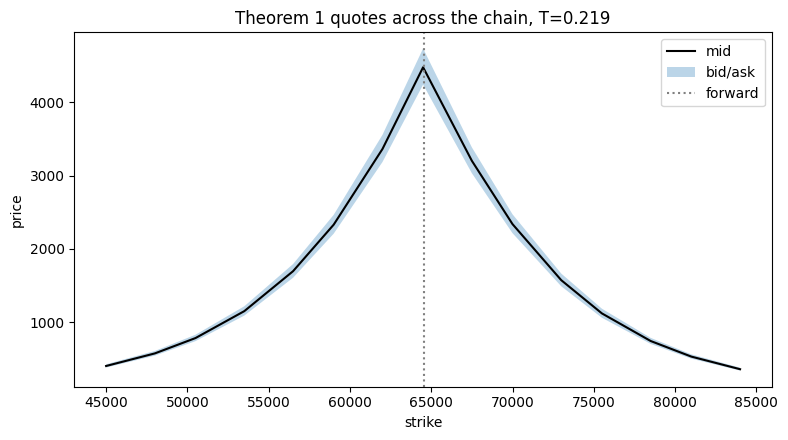

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(chain_df.K, chain_df.mid, 'k-', label='mid')
ax.fill_between(chain_df.K, chain_df.bid, chain_df.ask, alpha=0.3, label='bid/ask')
ax.axvline(F0, color='gray', linestyle=':', label='forward')
ax.set_xlabel('strike'); ax.set_ylabel('price')
ax.set_title(f'Theorem 1 quotes across the chain, T={T0:.3f}')
ax.legend()
plt.tight_layout()

## What this doesn't cover yet

This is the complete-market case only — quotes independent of inventory because continuous frictionless hedging is assumed. The paper's next two regimes build directly on this module:

- **Section III (illiquid underlying, Theorems 2–3):** the dealer must also quote the stock and can't hedge continuously, so premiums start tilting with net Delta. Needs a stateful inventory tracker (this notebook only ever varies `q_o` as a sweep parameter, never persists it).
- **Section IV (stochastic vol + jump risk, Theorems 4–5):** premiums tilt with net Gamma and Vega instead, scaled by a coefficient that depends on vol-of-implied-vol (`alpha`) — which needs a *history* of fitted surfaces to estimate, not a single snapshot like `surf` here.

Fill-intensity calibration (`market_making.calibration`) is now built, but it has real limitations worth keeping in mind:
- It fits a single `lambda_o` from whatever recent window of trades the API happens to return — option order flow is not a stationary Poisson process (it clusters around funding times and news), so this is a snapshot estimate, not a constant.
- The linear form `C - D*eps` is still an approximation to the true (visibly convex) empirical survival curve — good enough for the right order of magnitude, not a tight fit.
- Pooling across strikes assumes relative (fraction-of-mark) liquidity is comparable across the pooled instruments; very differently-shaped smiles/skews could violate that.